# Notebook 1

# Workload, Datasets und Python-Baseline

Hier: was gemessen wird, wo es läuft, und wogegen verglichen wird (Python als  Referenz). Die eigentliche Mechanik der Rust Implementation kommt in `02_ceilings.ipynb`.


In [6]:
# bench.db loading setup
import sqlite3
import re
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Hier noch den path ändern, falls bench.db woanders liegt
DB_PATH = Path('../../logs/bench.db')
assert DB_PATH.exists(), f'bench.db not found at {DB_PATH.resolve()}'

with sqlite3.connect(DB_PATH) as _conn:
    raw = pd.read_sql_query('SELECT * FROM runs', _conn)

print(f'loaded {len(raw):,} rows across {raw.build.nunique()} builds, '
      f'{raw.threads.nunique()} thread counts, {raw.label.nunique()} labels')

loaded 2,555 rows across 54 builds, 15 thread counts, 97 labels


In [7]:
# Helferfunktionen für die Analyse der Benchmarks

def parse_dataset(label):
    """Map a bench.db `label` string to a canonical dataset name."""
    if label.startswith('ood_') or 'c1024' in label:
        return 'c1024_56gb'
    if label.startswith('variance_'):
        return 'c256_56gb'
    # Fine-t sweep experiments für c256_56gb
    if label.startswith('lennart_c256_56gb_') or label.startswith('lennart_56gb_'):
        return 'c256_56gb'
    m = re.match(r'(?:main|numa)_(\d+gb)_', label)
    return f'c256_{m.group(1)}' if m else None

raw['dataset'] = raw['label'].apply(parse_dataset)

def q(*, builds=None, threads=None, dataset=None, suppress=True, agg='median'):
    """Slice the runs table by (build, threads, dataset) and aggregate over reps.

    Returns one row per (build, threads) with median wall_s + mean counters.
    """
    df = raw.copy()
    if suppress is not None:
        df = df[df.suppress_results == int(suppress)]
    if builds is not None:
        df = df[df.build.isin(builds if isinstance(builds, (list, tuple)) else [builds])]
    if threads is not None:
        df = df[df.threads.isin(threads if isinstance(threads, (list, tuple)) else [threads])]
    if dataset is not None:
        df = df[df.dataset == dataset]
    if df.empty:
        return df
    metrics = ['wall_s', 'ipc', 'l1_misses', 'llc_misses', 'llc_bw_gbs', 'branch_misses']
    g = df.groupby(['build', 'threads'])
    out = g[metrics].median() if agg == 'median' else g[metrics].mean()
    out['n_reps'] = g.size()
    return out.reset_index().sort_values(['build', 'threads'])

def compare(baseline, ablation, *, threads, dataset, suppress=True):
    """Side-by-side wall + IPC + LLC-miss for baseline vs ablation across t."""
    base = q(builds=[baseline], threads=threads, dataset=dataset, suppress=suppress)
    abl = q(builds=[ablation], threads=threads, dataset=dataset, suppress=suppress)
    if base.empty or abl.empty:
        return pd.DataFrame()
    m = base[['threads','wall_s','ipc','llc_misses']].merge(
        abl[['threads','wall_s','ipc','llc_misses']],
        on='threads', suffixes=(f'_{baseline}', f'_{ablation}'))
    m['ratio_wall'] = m[f'wall_s_{ablation}'] / m[f'wall_s_{baseline}']
    m['delta_ipc'] = m[f'ipc_{ablation}'] - m[f'ipc_{baseline}']
    return m

def ci95(series):
    """5-rep 95% CI half-width via Welch-style t(4) ≈ 2.776."""
    import statistics, math
    n = len(series)
    if n < 2:
        return 0.0
    sd = statistics.stdev(series)
    return 2.776 * sd / math.sqrt(n)

def delta_ci(baseline_walls, ablation_walls):
    """Return (mean_delta_pct, ci95_pct_half) for ablation vs baseline."""
    import statistics, math
    n_a, n_b = len(baseline_walls), len(ablation_walls)
    m_a, m_b = statistics.mean(baseline_walls), statistics.mean(ablation_walls)
    sd_a = statistics.stdev(baseline_walls) if n_a > 1 else 0
    sd_b = statistics.stdev(ablation_walls) if n_b > 1 else 0
    diff = m_b - m_a
    se = math.sqrt(sd_a**2/n_a + sd_b**2/n_b)
    half = 2.776 * se
    return 100*diff/m_a, 100*half/m_a

def datasets_available():
    return raw[raw.dataset.notna()].groupby('dataset').agg(
        n_rows=('id','count'), n_builds=('build','nunique'),
        threads=('threads', lambda s: sorted(s.unique())))

print('helpers loaded: q(), compare(), ci95(), delta_ci(), parse_dataset(), datasets_available()')
datasets_available()

helpers loaded: q(), compare(), ci95(), delta_ci(), parse_dataset(), datasets_available()


,n_rows,n_builds,threads
dataset,,,
c1024_56gb,426,16,"[1, 8, 16, 32, 48, 64, 96]"
c256_10gb,693,20,"[1, 8, 16, 32, 64, 96]"
c256_30gb,546,19,"[1, 8, 16, 32, 64, 96]"
c256_56gb,890,34,"[1, 8, 12, 14, 16, 18, 20, 24, 28, 32, 48, 64,..."


## 2. Workload, Datasets, Parameter-Sweeps

### 2.1 Hardware

Zwei-Socket **Intel Xeon Platinum 8468H** (Sapphire Rapids):

| | Wert |
|---|---|
| Physical / logical cores | 48+48 pro Socket -> 96 phys / 192 logical |
| Socket | 2 (NUMA nodes 0, 1) |
| DDR5 Bandwidth | ~300 GB/s pro Socket, ~600 GB/s gesamt |
| L3 Cache | 105 MiB pro Socket (nicht geteilt zwischen Socketn) |
| Cross-Socket UPI | NUMA distance 21 vs local 10 → ~2.1× Strafe |
| SIMD | AVX-512, AVX-512_FP16 |

### 2.2 Query Workload

10.000 Perzentilprädikate der Form `(percentile p, operator op ∈ {lt,gt}, threshold τ)`. Dieselbe kanonische Query-Datei (`queries/all.zst`) als Symlink über alle Datasets, u.a. sind Query-Eigenschaften konstant.

### 2.3 Die vier Datasets

Alle aus GitTables via Histogramm-Extraktion -> MiniBatchKMeans -> Rebinning Index. Variieren entlang zweier variabledimensionen: `n_hists` (Skala) und `hists/cluster` (Density).

### 2.4 Build-Axen (Cargo Features)

Die Flags die tatsächlich in Messungen variieren:

| Flag | Effekt |
|---|---|
| (default) | SoA Layout, scalar `partition_point`, glibc malloc |
| `simd` | AVX-512 Vergleich in binary-search Innerloop |
| `f16` | Perzentilwerte als f16 statt f32 → halbiert Index-Größe |
| `aos` | Array-of-Structs Layout (Negativkontrolle für L3-Druck) |
| `packed-ids` | Per-cluster bit-packed IDs (`⌈log₂(cluster_size)⌉` bits) |
| `pooled` | Preallokierter Output-Buffer (eliminiert `flat_map+collect`) |
| `pin-cores` | Rayon workers auf distinct physical cores gepinnt |
| `cluster-prefetch` | `_mm_prefetch` für cluster c+1 während c läuft |
| `mimalloc` | Ersetzt glibc arena mutex durch per-thread sharded free-lists |
| `query-batch` | Column-centric Innerloop innerhalb K-Query batches |
| `morsel` | Phase-aligned cooperative-caching Scheduler (Chase-Lev) |
| `local-ids` (4 Varianten) | Per-cluster ID-Reindexierung |
| `horizontal-simd` | AVX-512 über 16 queries lockstep (Polychroniou) |
| `pgm` | Learned-Index Beschleunigung der binary search |
| **`bestofsuite`** | `pooled f16 simd pin-cores cluster-prefetch mimalloc`, der "Optimal" Kombi build |

### 2.5 Laufzeit-Dimensionen

| Axis | Werte |
|---|---|
| Thread count `t` | 1, 8, 12, 14, 16, 18, 20, 24, 28, 32, 48, 64, 96, 128, 192 (>96 = Hyperthreading) |
| `FAINDER_QUERY_BATCH` | 16, 32, 64, 128, 256 (nur bei `query-batch`) |
| `numactl` | unpinned, single-socket, interleave, cross-socket-forced |
| `suppress_results` | True (Suchphase isoliert) / False (mit Result-Emission) |


In [8]:
# Zusammenfassung pro Dataset, unten die vier Workloads die überall referenziert werden
ds_summary = pd.DataFrame({
    'dataset':       ['c256_10gb', 'c256_30gb', 'c256_56gb', 'c1024_56gb'],
    'parquet':       ['~10 GB', '~30 GB', '~56 GB', '~56 GB (OOD)'],
    'histograms':    [323_719, 996_632, 5_017_619, 5_017_619],
    'k_target':      [256, 256, 256, 1024],
    'k_effective':   [129, 184, 191, 610],
    'hists_per_cluster': [2_510, 5_420, 26_300, 8_200],
})
ds_summary


,dataset,parquet,histograms,k_target,k_effective,hists_per_cluster
0,c256_10gb,~10 GB,323719,256,129,2510
1,c256_30gb,~30 GB,996632,256,184,5420
2,c256_56gb,~56 GB,5017619,256,191,26300
3,c1024_56gb,~56 GB (OOD),5017619,1024,610,8200


### 2.3.1 Die vier Datasets im Detail

Namenskonvention **`c{K_target}_{size_tag}`**: `K_target` ist das MiniBatchKMeans Ziel (fast immer weniger effektive Cluster durch verschmelzende Zentroiden). `size_tag` = Größe des Parquet-Korpus, nicht Index

| Dataset | n_hists | K_eff | Hists/Cluster | Per-Cluster f32 Array | Rolle |
|---|---|---|---|---|---|
| `c256_10gb` | 324 K | 129 | ~2.5 K | ~10 KB (in L1d) | kleiner Test |
| `c256_30gb` | 997 K | 184 | ~5.4 K | ~22 KB (in L1d) | mittel |
| `c256_56gb` | **5.02 M** | 191 | ~26 K | **~105 KB (überschreitet L1d)** | primärer Workload |
| `c1024_56gb` | 5.02 M | 610 | ~8.2 K | ~33 KB (in L1d) | **OOD** (12) |

- Zweidimensionaler Parameter-Space: statt Linie,  Skala (`n_hists`) und Density (`hists/cluster`) unabhängig variiert. Vier Punkte in `(n_hists, K)` machen die Dispatch Policy generalisierbar und testbar machen.

- c256_56gb ist der primäre Workload:  hier binden Decken 2, 3, und 4 alle fünf Negativkomposierung Instanzen und der 4-Config NUMA Probe

- c1024_56gb ist der OOD Punkt:  gleicher Parquet Korpus, aber K-means Ziel 1024 statt 256 → 3.2× dünnere Cluster bei gleichem n_hists. Testet ob Decken und Dispatch bei anderer Density halten.


## 3. Python Basisversion (der Anker)

Die Python-Baseline läuft die unmodifizierte Fainder Library (Fainder Approx) (`FainderMode.LOW_MEMORY`), die Variante deren Query-Phase die Thesis im Proposal adressiert. `FAINDER_NO_RUST=1`, with-results Modus.

Untersuchiung der vier-Decken-Charakterisierung, fünf Instanzen Negativ komposierungsmuster, Pre-run Deckenidentifizierungs Methode via dem Dispatcher


In [9]:
# Python Baseline wall + IPC, with-results Modus
py = raw[(raw.build == 'python') & (raw.suppress_results == 0)]
py_summary = py.groupby(['dataset', 'threads']).agg(
    wall_s=('wall_s', 'median'),
    ipc=('ipc', 'median'),
    n_reps=('id', 'count'),
).reset_index()
py_summary


,dataset,threads,wall_s,ipc,n_reps
0,c256_10gb,1,610.172,2.298,5
1,c256_10gb,8,601.469,2.339,5
2,c256_10gb,16,599.670,2.347,8
3,c256_10gb,32,596.268,2.349,5
4,c256_10gb,64,600.246,2.335,5
5,c256_10gb,96,601.617,2.334,5
6,c256_30gb,16,1890.311,2.227,8
7,c256_56gb,16,858.941,2.385,5


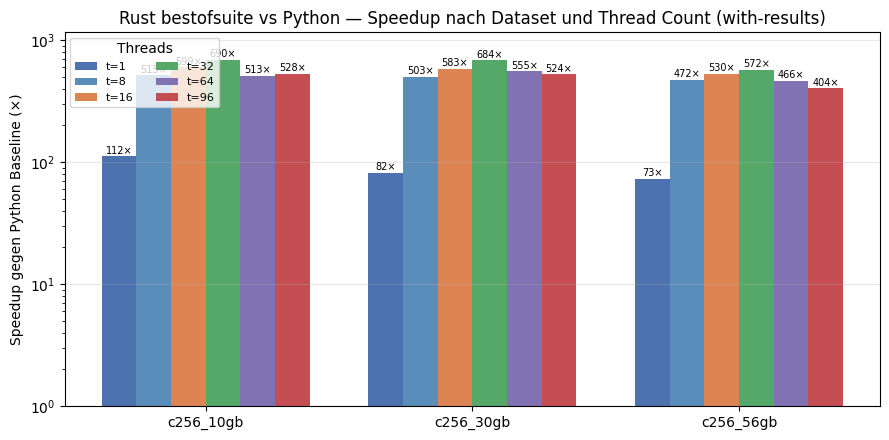

In [10]:
# Plot: Rust bestofsuite Speedup vs Python, nach Dataset und t
# Python ist GIL-bound → wall ist über alle t praktisch flach. Wir nehmen
# den Median über alle verfügbaren t-Werte pro Dataset als Python-Referenz
# und teilen Rust bestofsuite bei jedem t durch diese Zahl.

import matplotlib.pyplot as plt
import numpy as np

def python_ref(ds):
    """Median Python wall_s per dataset, mit Subsample-Extrapolation für 56gb."""
    py = raw[(raw.build == 'python') & (raw.dataset == ds) & (raw.suppress_results == 0)].copy()
    if py.empty:
        return None, False
    is_subsample = py.label.str.contains('subsample1k', regex=False, na=False)
    py.loc[is_subsample, 'wall_s'] = py.loc[is_subsample, 'wall_s'] * 10
    used_subsample = bool(is_subsample.any() and not (~is_subsample).any())
    return py.wall_s.median(), used_subsample

fig, ax = plt.subplots(figsize=(9, 4.5))
datasets = ['c256_10gb', 'c256_30gb', 'c256_56gb']
threads = [1, 8, 16, 32, 64, 96]
x = np.arange(len(datasets)); width = 0.13
colors = ['#4c72b0', '#5b8dbb', '#dd8452', '#55a868', '#8172b3', '#c44e52']

py_walls = {ds: python_ref(ds) for ds in datasets}

for i, t in enumerate(threads):
    speedups = []
    for ds in datasets:
        py_wall, _ = py_walls[ds]
        rust = raw[(raw.build == 'bestofsuite') & (raw.dataset == ds) & (raw.threads == t) & (raw.suppress_results == 0)]
        if py_wall is None or rust.empty:
            speedups.append(0)
        else:
            speedups.append(py_wall / rust.wall_s.median())
    pos = x + (i - 2.5) * width
    bars = ax.bar(pos, speedups, width, label=f't={t}', color=colors[i])
    for b, s in zip(bars, speedups):
        if s > 0:
            ax.text(b.get_x() + b.get_width()/2, s * 1.05, f'{s:.0f}×', ha='center', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(datasets)
ax.set_ylabel('Speedup gegen Python Baseline (×)')
ax.set_title('Rust bestofsuite vs Python — Speedup nach Dataset und Thread Count (with-results)')
ax.legend(title='Threads', loc='upper left', ncol=2, fontsize=8); ax.grid(axis='y', alpha=0.3); ax.set_yscale('log')
ax.set_ylim(1, ax.get_ylim()[1] * 1.5)

for xi, ds in zip(x, datasets):
    py_wall, from_subsample = py_walls[ds]
    if py_wall is None:
        ax.text(xi, 1.3, 'Python-Baseline\nnoch nicht gemessen', ha='center',
                fontsize=8, color='gray', style='italic')
    # elif from_subsample:
        # ax.text(xi, ax.get_ylim()[1] * 0.55,
        #         '* 1K-Query Subsample\n× 10 extrapoliert',
        #         ha='center', fontsize=8, color='#7a4a1a', style='italic',
        #         bbox=dict(facecolor='#fff2e6', edgecolor='#dd8452', boxstyle='round,pad=0.3'))

plt.tight_layout(); plt.show()


### 3.3 IPC ≠ Speed 

Python bei `t=16` auf `c256_30gb` hat IPC ≈ 2.3, welches höher ist als Rust default (~1.7 in derselben Zelle). Trotzdem ist Python ~2 Größenordnungen langsamer.

Es schliesst sich: IPC ist Diagnostik, keine zu optimierende Metrik. Pythons Interpreter-Dispatch, Bytecode-Dekodierung, Attribut-Lookups retiren als lange Sequenzen L1-residenter Instructions mit hoher IPC weil sie nicht auf Memory stallen. sie machen einfach zu viel. Rusts engere Innerloop retirt weniger Instructions gerade weil sie mehr Cycles aufs Warten auf Memory verwendet statt auf Bookkeeping.

SDie ignatur einer funktionierenden bandwidth-end Optimierung ist das  IPC leicht verringert (mehr Cycles im Memory-Wait) UND  wall senkt (weniger Gesamt-Instructions und/oder weniger Memory-Stalls). 3.11 `local-ids` ist das saubere Gegenbeispiel: senkt IPC auf falsche Art (durch dTLB-Stalls ohne etwas zu entfernen) aber die wall verdreifacht sich. 

Schlussfolgerung: IPC-Senkung ist notwendig aber nicht hinreichend
